# Resolving MLP Issues

### Table of content
1. Initialization
    1. softmax confidently wrong
    2. tanh saturation

In [1]:
# data preprocessing

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# build the vocabulary of characters and mappings to/from integers
words = open('../data/names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(f"{vocab_size=}")

# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context) # its just appending the list objects, not the list values
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(f"{X.shape, Y.shape}=")
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%


vocab_size=27
(torch.Size([182625, 3]), torch.Size([182625]))=
(torch.Size([22655, 3]), torch.Size([22655]))=
(torch.Size([22866, 3]), torch.Size([22866]))=


## Initialization

number of parameters: 11897
      0/    200: 28.3854


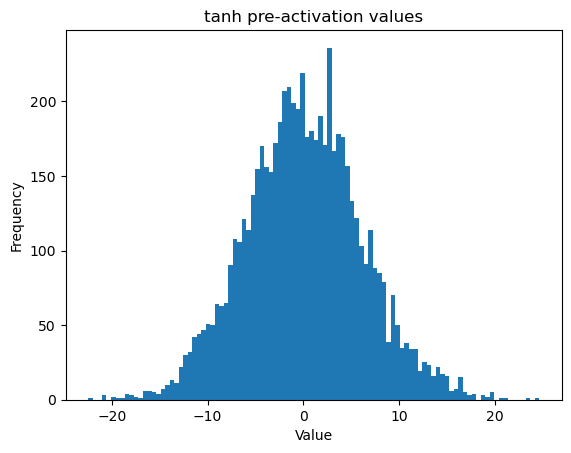

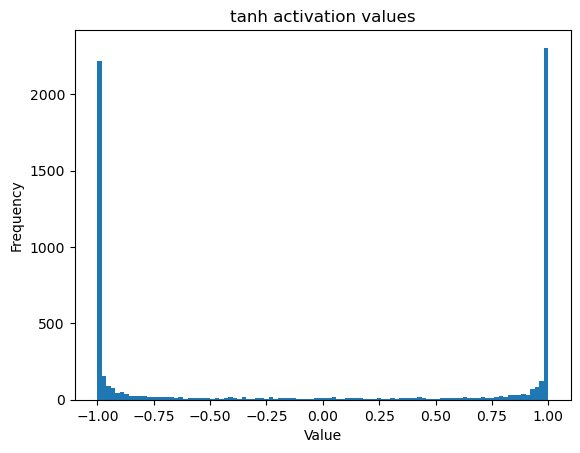

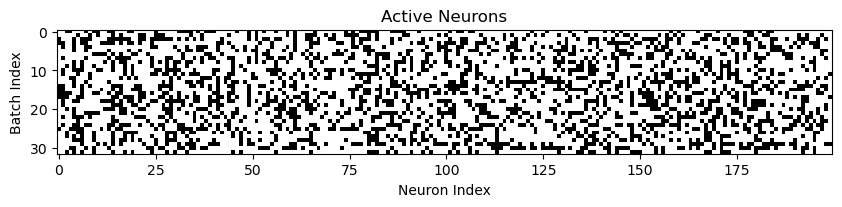

In [6]:
# definiing the model
n_embd = 10
n_hidden = 200

torch.manual_seed(42)

# input layer
C  = torch.randn((vocab_size, n_embd)) # embedding table

# hidden layer
W1 = torch.randn((n_embd * block_size, n_hidden))
b1 = torch.randn(n_hidden)

# output layer
W2 = torch.randn((n_hidden, vocab_size))
b2 = torch.randn(vocab_size)

parameters = [C, W1, b1, W2, b2]
print(f"number of parameters: {sum(p.nelement() for p in parameters)}")
for p in parameters:
  p.requires_grad = True


# training the model
max_steps = 200
batch_size = 32

lossi = []
for i in range(max_steps):
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix]
  
  # forward pass
  # embedding layer
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors (32, 3 * 10)
  
  # hidden layer
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation (32, 200)
  h = torch.tanh(hpreact) # hidden layer
  
  # output layer
  logits = h @ W2 + b2
  
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 20 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

  plt.hist(hpreact.view(-1).tolist(), bins=100)
  plt.title("tanh pre-activation values")
  plt.xlabel("Value")
  plt.ylabel("Frequency")
  plt.show()
  
  plt.hist(h.view(-1).tolist(), bins=100)
  plt.title("tanh activation values")
  plt.xlabel("Value")
  plt.ylabel("Frequency")
  plt.show()
  
  plt.figure(figsize=(10, 20))
  plt.imshow(h.abs() > 0.99, cmap='gray') # the black pixels are the active neurons, the white pixels are the dead neurons
  plt.title("Active Neurons")
  plt.xlabel("Neuron Index")
  plt.ylabel("Batch Index")
  plt.show()
  break

- so there are two problems
1. high initial loss
2. tanh saturation problem

### Softmax confidently wrong

In [7]:
# Issue : High Initial Loss then expected Probabilistically i.e -ln(1/27) = 3.29 but we get 27

# Cause : 1. because we have normal distribution (because of tanh) instead of uniform distribution
#         2. as you increase the scale(variance) of normal distribution the activation of softmax will worse because of exponential function, (think about exponential curve)  

# Fix : lower the scale of normal distribution (i.e. multiply by 0.1)

torch.manual_seed(42)

t = torch.randn(27)
prob = F.softmax(t, dim=0)
print(-prob.log().mean())

t = torch.randn(27) * 10
prob = F.softmax(t, dim=0)
print(-prob.log().mean())

t = torch.randn(27) * 0.1
prob = F.softmax(t, dim=0)
print(-prob.log().mean())

tensor(3.8956)
tensor(27.4693)
tensor(3.2979)


In [8]:
# nothing is changed from previous code except W2 is scale down to 0.01, b1 = b2 = 0 because we want to scale down the logits going into the cross_entropy loss function
# definiing the model
n_embd = 10
n_hidden = 200

torch.manual_seed(42)

# input layer
C  = torch.randn((vocab_size, n_embd)) # embedding table

# hidden layer
W1 = torch.randn((n_embd * block_size, n_hidden))
b1 = torch.randn(n_hidden) * 0

# output layer
W2 = torch.randn((n_hidden, vocab_size)) * 0.01
b2 = torch.randn(vocab_size) * 0

parameters = [C, W1, b1, W2, b2]
print(f"number of parameters: {sum(p.nelement() for p in parameters)}")
for p in parameters:
  p.requires_grad = True


# training the model
max_steps = 200
batch_size = 32

lossi = []
for i in range(max_steps):
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix]
  
  # forward pass
  # embedding layer
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors (32, 3 * 10)
  
  # hidden layer
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation (32, 200)
  h = torch.tanh(hpreact) # hidden layer
  
  # output layer
  logits = h @ W2 + b2
  
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 20 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')


number of parameters: 11897
      0/    200: 3.3049
     20/    200: 2.5406
     40/    200: 2.7886
     60/    200: 2.4455
     80/    200: 2.5286
    100/    200: 2.7164
    120/    200: 2.7664
    140/    200: 2.5391
    160/    200: 2.5408
    180/    200: 2.9410


### Tanh saturation

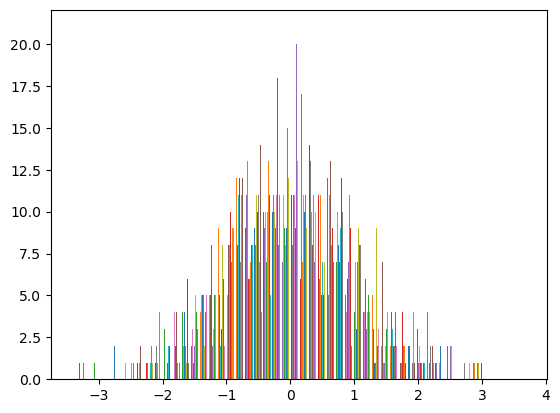

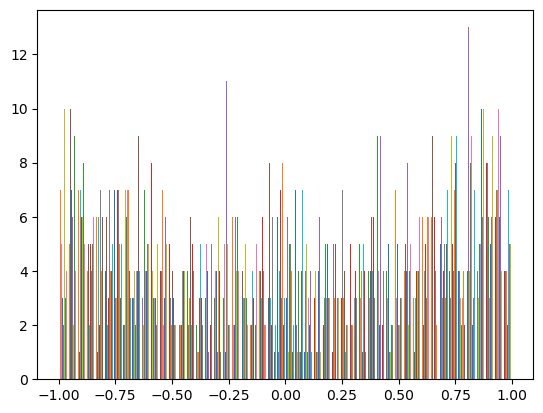

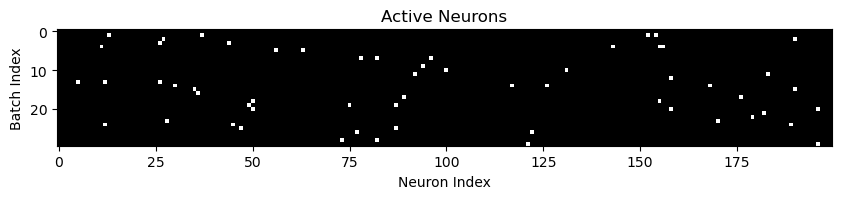

In [9]:
# to keep tanh active the pre activations should have N(0, 1)
t = torch.randn(30, 200)
plt.hist(t.tolist(), bins=50);
plt.show()

plt.hist(t.tanh().tolist(), bins=50);
plt.show()

plt.figure(figsize=(10, 20))
plt.imshow(t.tanh().abs() > 0.99, cmap='gray') # the black pixels are the active neurons, the white pixels are the dead neurons
plt.title("Active Neurons")
plt.xlabel("Neuron Index")
plt.ylabel("Batch Index")
plt.show()

- The concept of dead neuron
1. a neuron is just a 1D tensor of it's input weights
2. if it's input weight are high in such a way that the output of it's affine function is far away from tanh active region(in flat tails) then i get's zero gradient, and it just knock out and will never learn 
3. tanh = (math.exp(2*x) - 1)/(math.exp(2*x) + 1) and it's gradient = (1 - tanh(x)**2) * out.grad
4. so if tanh = +/- 1 then it's gradient is equal to zero (vanishes) but if it is equal to 0 the gradient is smoothly pass through the layer which is good for training
5. N(0, 1) helps to keep pre activation in active range of tanh and keeps gradient healthy

std of preactivation: 1.0552430152893066


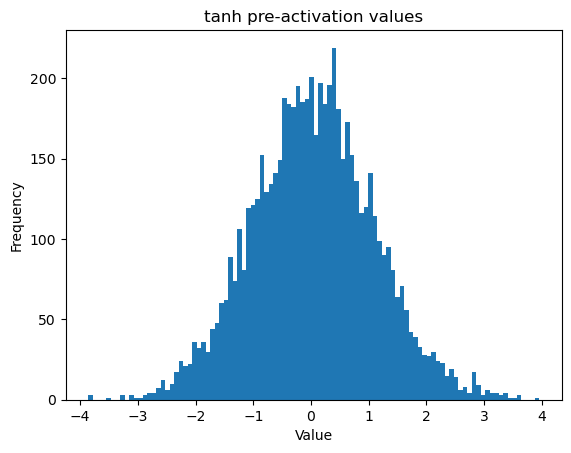

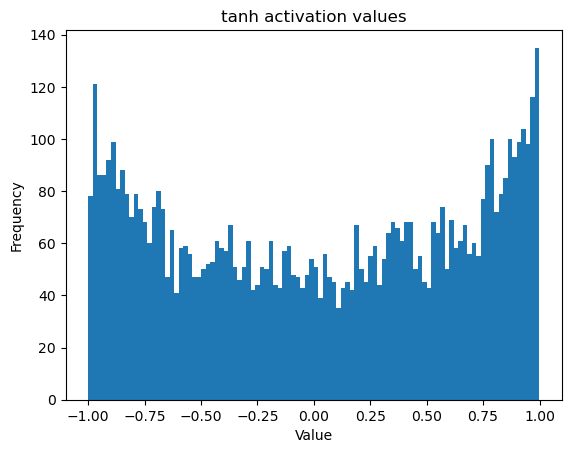

In [10]:
# fixing the preactivation distribution by applying fan in normalization to W1

n_embd = 10
n_hidden = 200

torch.manual_seed(42)

# input layer
C  = torch.randn((vocab_size, n_embd)) # embedding table

# hidden layer
W1 = torch.randn((n_embd * block_size, n_hidden)) * (1/(n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden) * 0
"""
The problem : If x and w are both drawn from N(0,1), then for a single neuron: h = x₁w₁ + x₂w₂ + ... + xₙwₙ
The variance of each xᵢwᵢ is 1, so: Var(h) = n x Var(xᵢwᵢ) = n x 1 = n
The standard deviation of h becomes √n — it grows with the number of inputs (fan-in). that is why it is divided by fan-in to keep variance constant and keep logits with in active range of tanh to keep gradients healthy at initialization
"""
"""
the 5/3 is the gain to keep activations after tanh healthy, it is driven based on Pre-activations follow approximately N(0, 1)
"""
# training portion
emb = C[Xb] # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors (32, 3 * 10)
  
# hidden layer
hpreact = embcat @ W1 + b1 # hidden layer pre-activation (32, 200)

print(f"std of preactivation: {hpreact.std()}") # it's variance is 1 because we have applied fan in normalization
plt.hist(hpreact.view(-1).tolist(), bins=100)
plt.title("tanh pre-activation values")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

h = torch.tanh(hpreact) # hidden layer

plt.hist(h.view(-1).tolist(), bins=100)
plt.title("tanh activation values")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


In [11]:
# compensating for the squashing of tanh (kaiming He)
# because if each layer activation function squashes the varience then at one point it becomes too small and the model will not learn, so we need to compensate for that by scaling up the pre-activation values
# Important : it does't scale up activations to 1 instead it scales up about 0.8 and then it stablizes about 0.7-0.8

t = torch.randn(10000) * 5/3
print(f"std of t: {t.std()}")
activation = t.tanh()
print(f"std of activation: {activation.std()}")



std of t: 1.6535083055496216
std of activation: 0.756594717502594


In [12]:
# Final fixed initialization code

# definiing the model
n_embd = 10
n_hidden = 200

torch.manual_seed(42)

# input layer
C  = torch.randn((vocab_size, n_embd)) # embedding table

# hidden layer
W1 = torch.randn((n_embd * block_size, n_hidden)) * 5/3 * (1/(n_embd * block_size)**0.5) # we have applied fan in normalization and also compensating for the squashing of tanh
b1 = torch.randn(n_hidden) * 0

# output layer
W2 = torch.randn((n_hidden, vocab_size)) * 0.01
b2 = torch.randn(vocab_size) * 0

parameters = [C, W1, b1, W2, b2]
print(f"number of parameters: {sum(p.nelement() for p in parameters)}")
for p in parameters:
  p.requires_grad = True


# training the model
max_steps = 200
batch_size = 32

lossi = []
for i in range(max_steps):
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix]
  
  # forward pass
  # embedding layer
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors (32, 3 * 10)
  
  # hidden layer
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation (32, 200)
  h = torch.tanh(hpreact) # hidden layer
  
  # output layer
  logits = h @ W2 + b2
  
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 20 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')


number of parameters: 11897
      0/    200: 3.2957
     20/    200: 2.5728
     40/    200: 2.7679
     60/    200: 2.4237
     80/    200: 2.5490
    100/    200: 2.7537
    120/    200: 2.8185
    140/    200: 2.5638
    160/    200: 2.4720
    180/    200: 2.9740


## Batch normalization

In [13]:
# problem: unstable training over deep networks
# reason: at the training time the pre activations get out of tanh active region and become dead
# solution: normalizing features of batches to keep them in active tanh gradient region during training

# defining the model parameters
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)

# input layer
C  = torch.randn((vocab_size, n_embd),            generator=g) # embedding table

# hidden layer
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) /((n_embd * block_size)**0.5)



# b1 = torch.randn(n_hidden,                        generator=g)  * 0.01 # batch norm handel it

# output layer
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01 # it helps to make softmax output more uniform at the beginning of training, which can help with gradient flow and convergence otherwise the softmax is confident about one class and the gradients are very small
b2 = torch.randn(vocab_size,                      generator=g) #* 0

# BatchNorm parameters
# applied on preactivation logits of hidden layer (W1)
bngain = torch.ones((1, n_hidden)) # per feature or per column
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden)) # you can take it out of the training loop also, because it is the separate step before inference after training
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [14]:
# training the model with batch normalization
max_steps = 20000
batch_size = 32 # how many examples to process in parallel with in a matrix multiply
lossi = [] # track the loss

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  # embedding layer
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors (32, 3 * 10)
  
  # hidden layer
  hpreact = embcat @ W1 #+ b1 # (32, 30) @ (30, 200) => (32, 200) hidden layer pre-activation (32, 200)
  # # BatchNorm sub layer
  # # -------------------------------------------------------------
  bnmeani = hpreact.mean(0, keepdim=True) # (1, 32)
  bnstdi = hpreact.std(0, keepdim=True) # (1, 32)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # main componenet of batch norm
  # it is just normalizing the outputs of each neuron across the batch, and then scaling and shifting it with gain and bias parameters
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani # it is just a way to calculating the mean of whole dataset, you can do it separately also 
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi # 0.001 is the momentum
  # # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  
  # output layer
  logits = h @ W2 + b2 
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 1000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  
plt.plot(lossi)

      0/  20000: 3.8443
   1000/  20000: 2.4793
   2000/  20000: 2.3689
   3000/  20000: 2.1516
   4000/  20000: 1.9926
   5000/  20000: 2.1167
   6000/  20000: 2.1112
   7000/  20000: 2.3115


KeyboardInterrupt: 

In [ ]:
# evaluating the mlp with batch norm

def split_loss(split): # evaluate the loss on train, val, test splits
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')
split_loss('test')

train 2.2067389488220215
val 2.2192835807800293
test 2.221825122833252


## loss log

### original:
train 2.1245384216308594
val   2.168196439743042

### fix softmax confidently wrong:
train 2.07
val   2.13

### fix tanh layer too saturated at init:
train 2.0355966091156006
val   2.1026785373687744

### use semi-principled "kaiming init" instead of hacky init:
train 2.0376641750335693
val   2.106989622116089

### add batch norm layer
train 2.0668270587921143
val 2.104844808578491


## Pytorchifying everything

In [ ]:
# Let's train a deeper network
# The classes we create here are the same API as nn.Module in PyTorch

class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1): # the dim is the dimensions of columns
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd),            generator=g)
# layers = [
#   Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#   Linear(           n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
# ]

layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), Tanh(),
  Linear(           n_hidden, vocab_size, bias=False)
]

with torch.no_grad():
  # last layer: make less confident
  # shrink the logits by 10× Softmax is extremely sensitive to logit scale
  # layers[-1].gamma *= 0.1
  layers[-1].weight *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 0.3 #5/3#1#3 #5/3
      # if it is 1 : the subsequent tanh layers continuously squashes the preactivations, results in low saturation of tanh and gradient explosion
      # if it is 3 : results in high saturation of tanh and gradient vanishing
      # but if it is 5/3 : the preactivations are in the active region of tanh and the gradients are healthy, the std of activations after tanh is about 0.8 and then it stablizes about 0.7-0.8
       
      #(if not used with batch norm the std will shrink and the preactivations will be out of active region of tanh) if you make it 0.5 some thing happend to gradients 
      # if it is set to 1 the tanh squashes the preactivations (of the linear layer) too much and the gradients become very large, if it is set to 5/3 the preactivations are in the active region of tanh and the gradients are healthy

parameters = [C] + [p for layer in layers for p in layer.parameters()] # layer.parameters() returns a list of 2d tensors, the the parameters variable contains all the 2d tensors (parameters) in a 1d list
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

45970


In [ ]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = [] # 

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
    #  Tells PyTorch to keep gradients for the output of each layer. Normally, PyTorch only retains gradients for leaf tensors (parameters). This allows you to inspect the gradients flowing through intermediate layers for debugging/visualization
    # there are two types of gradients one of trainable parameters (in linear layers) and another of activation functions (tanh gradients) but pytorch generally did not store the gradients of activation functions, so we need to retain them to inspect them
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  if i >= 1000:
    break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.2958


## Visualisation and monitoring

layer 1 (      Tanh): mean -0.02, std 0.29, saturated: 0.00%
t.shape=torch.Size([32, 100])
layer 3 (      Tanh): mean -0.00, std 0.12, saturated: 0.00%
t.shape=torch.Size([32, 100])
layer 5 (      Tanh): mean -0.00, std 0.08, saturated: 0.00%
t.shape=torch.Size([32, 100])
layer 7 (      Tanh): mean -0.00, std 0.05, saturated: 0.00%
t.shape=torch.Size([32, 100])
layer 9 (      Tanh): mean -0.00, std 0.04, saturated: 0.00%
t.shape=torch.Size([32, 100])


Text(0, 0.5, 'logits count')

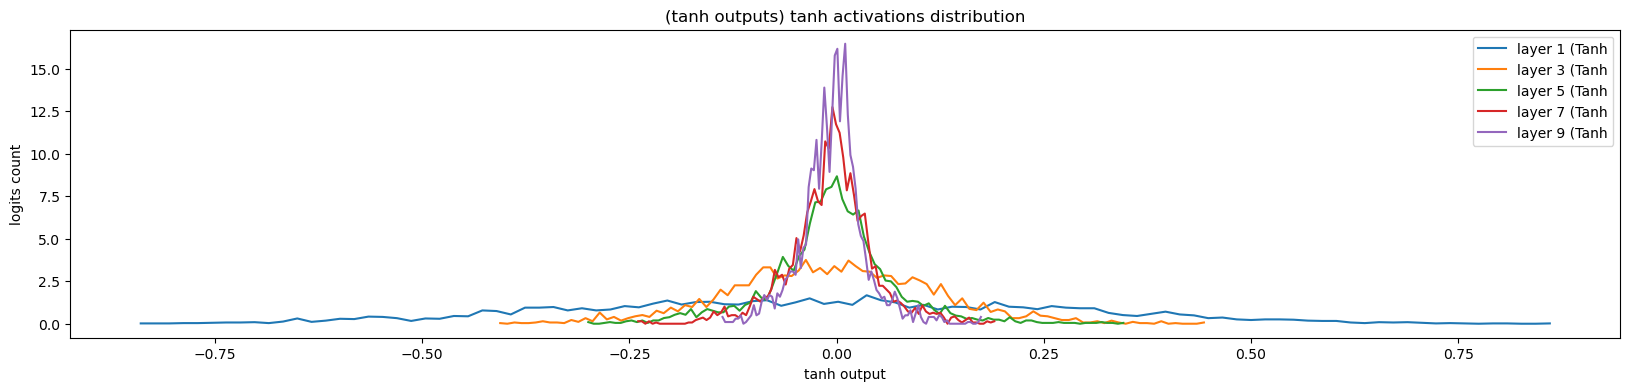

In [ ]:
# visualize histograms
# activation statistics in forward pass
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    print(f"{t.shape=}")
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    # plt.hist(t.view(-1).detach().numpy(), bins=100)
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends)
plt.title('(tanh outputs) tanh activations distribution')
plt.xlabel("tanh output")
plt.ylabel("logits count")

layer 1 (      Tanh): mean +0.000016, std 2.200685e-03
layer 3 (      Tanh): mean +0.000017, std 1.875702e-03
layer 5 (      Tanh): mean +0.000010, std 1.735474e-03
layer 7 (      Tanh): mean +0.000023, std 1.692641e-03
layer 9 (      Tanh): mean +0.000009, std 1.701660e-03


Text(0.5, 1.0, 'gradient distribution')

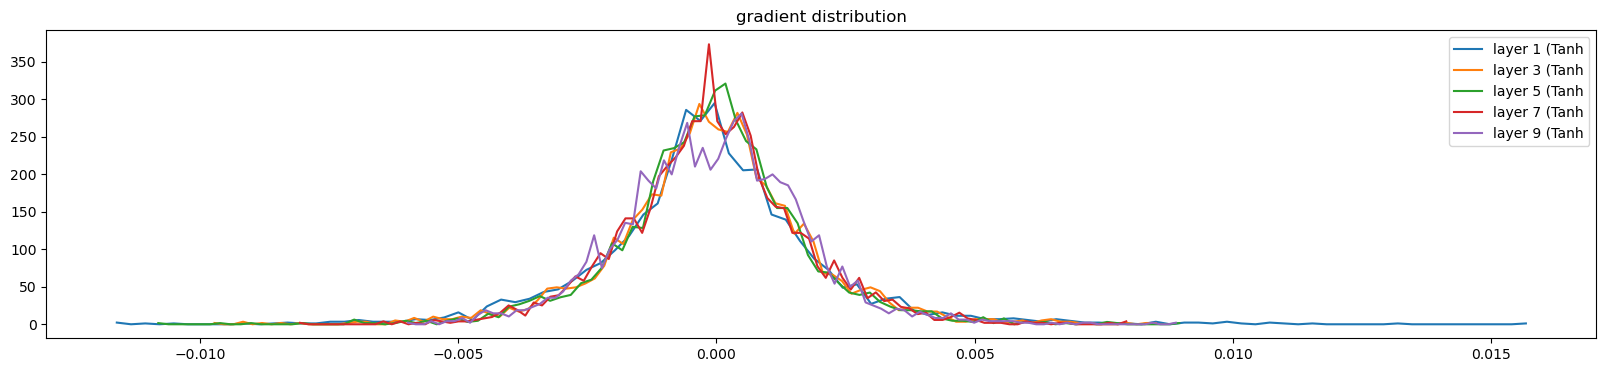

In [ ]:
# visualize histograms
# gradient statistics in backward pass
# visualizing the gradients of the tanh activation function at each layer to see if they are healthy or if they are vanishing/exploding
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')
# notice that the gradients of tanh at the extreme ends are zero
# the flat curve mean good

weight   (27, 10) | mean -0.000008 | std 8.133063e-04 | grad:data ratio 8.122623e-04
weight  (30, 100) | mean +0.000013 | std 1.165042e-03 | grad:data ratio 2.043097e-02
weight (100, 100) | mean +0.000003 | std 7.624997e-04 | grad:data ratio 2.499804e-02
weight (100, 100) | mean -0.000002 | std 6.603967e-04 | grad:data ratio 2.142332e-02
weight (100, 100) | mean -0.000004 | std 6.905315e-04 | grad:data ratio 2.248821e-02
weight (100, 100) | mean -0.000005 | std 6.585098e-04 | grad:data ratio 2.142428e-02
weight  (100, 27) | mean -0.000000 | std 1.822624e-03 | grad:data ratio 1.183734e-01


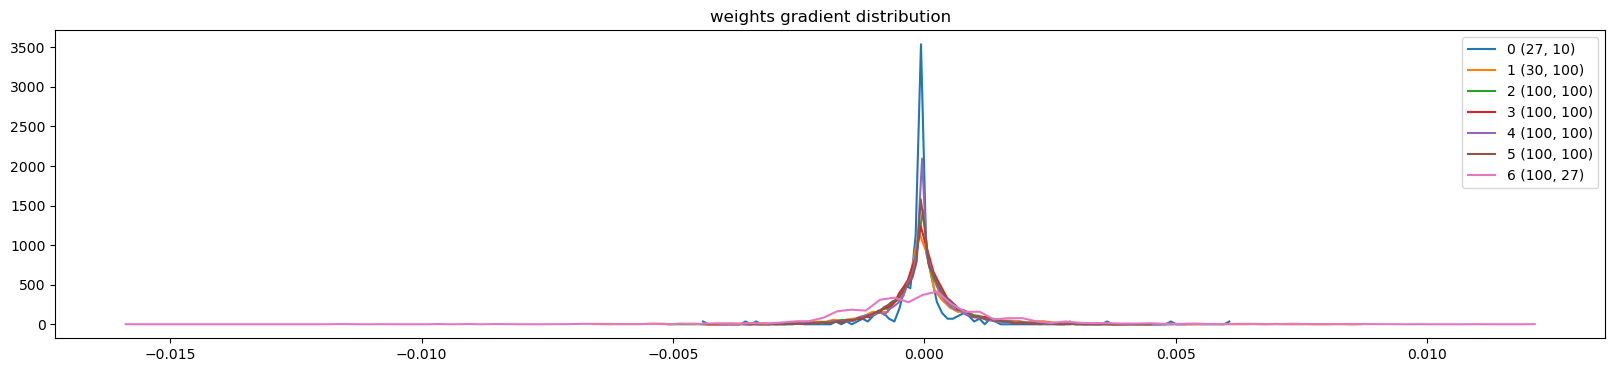

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

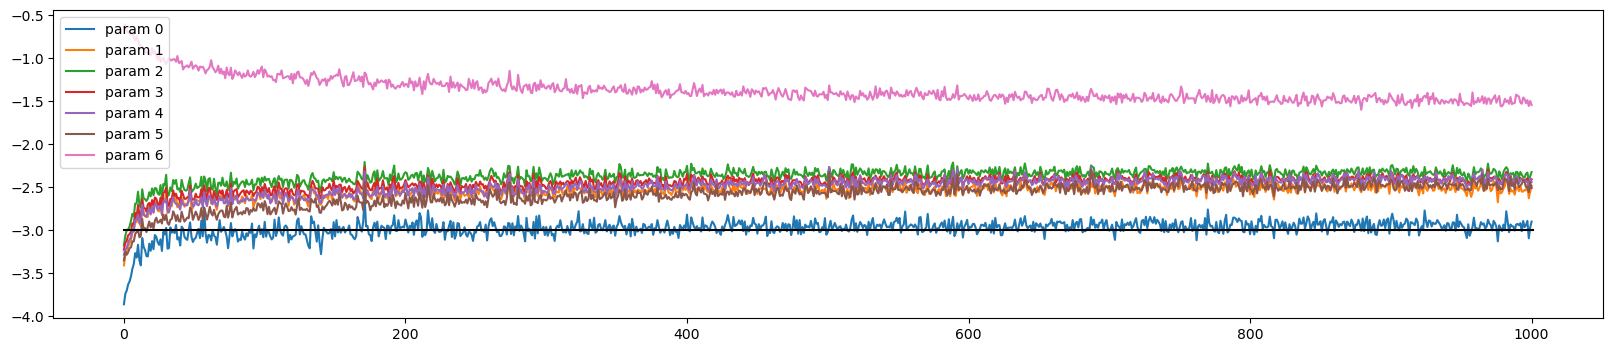

In [ ]:
# the update to data ratio should be around 1e-3, if it is too high then the learning rate is too high and if it is too low then the learning rate is too low
# the oulier pink line is due to the softmax init

# even thoug you are using batch norm the effect of change of gain still effect this plot, and you have to chnge learning rate to tackel it
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);



In [ ]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 2.3714733123779297
val 2.379171848297119


In [ ]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

carplie.
arlilei.
kimrix.
taty.
sacans.
ejanhnen.
den.
art.
kaqhi.
neroniahceriiv.
kaleigyh.
bma.
din.
quint.
sron.
warian.
quiroe.
padearyrix.
kaeelinsan.
edde.


In [ ]:
# DONE; BONUS content below, not covered in video

In [ ]:
# BatchNorm forward pass as a widget

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import scipy.stats as stats
import numpy as np

def normshow(x0):
  
  g = torch.Generator().manual_seed(2147483647+1)
  x = torch.randn(5, generator=g) * 5
  x[0] = x0 # override the 0th example with the slider
  mu = x.mean()
  sig = x.std()
  y = (x - mu)/sig

  plt.figure(figsize=(10, 5))
  # plot 0
  plt.plot([-6,6], [0,0], 'k')
  # plot the mean and std
  xx = np.linspace(-6, 6, 100)
  plt.plot(xx, stats.norm.pdf(xx, mu, sig), 'b')
  xx = np.linspace(-6, 6, 100)
  plt.plot(xx, stats.norm.pdf(xx, 0, 1), 'r')
  # plot little lines connecting input and output
  for i in range(len(x)):
    plt.plot([x[i],y[i]], [1, 0], 'k', alpha=0.2)
  # plot the input and output values
  plt.scatter(x.data, torch.ones_like(x).data, c='b', s=100)
  plt.scatter(y.data, torch.zeros_like(y).data, c='r', s=100)
  plt.xlim(-6, 6)
  # title
  plt.title('input mu %.2f std %.2f' % (mu, sig))

interact(normshow, x0=(-30,30,0.5));


interactive(children=(FloatSlider(value=0.0, description='x0', max=30.0, min=-30.0, step=0.5), Output()), _dom…

In [4]:
# Linear: activation statistics of forward and backward pass

g = torch.Generator().manual_seed(2147483647)

a = torch.randn((1000,1), requires_grad=True, generator=g)          # a.grad = b.T @ c.grad
b = torch.randn((1000,1000), requires_grad=True, generator=g)       # b.grad = c.grad @ a.T
c = b @ a
loss = torch.randn(1000, generator=g) @ c
a.retain_grad()
b.retain_grad()
c.retain_grad()
loss.backward()
print('a std:', a.std().item())
print('b std:', b.std().item())
print('c std:', c.std().item())
print('-----')
print('c grad std:', c.grad.std().item())
print('a grad std:', a.grad.std().item())
print('b grad std:', b.grad.std().item())

a std: 0.9875972270965576
b std: 1.0006722211837769
c std: 31.01241683959961
-----
c grad std: 0.9782556295394897
a grad std: 30.8818302154541
b grad std: 0.9666601419448853


In [5]:
# Linear + BatchNorm: activation statistics of forward and backward pass

g = torch.Generator().manual_seed(2147483647)

n = 1000
# linear layer ---
inp = torch.randn(n, requires_grad=True, generator=g)
w = torch.randn((n, n), requires_grad=True, generator=g) # / n**0.5
x = w @ inp
# bn layer ---
xmean = x.mean()
xvar = x.var()
out = (x - xmean) / torch.sqrt(xvar + 1e-5)
# ----
loss = out @ torch.randn(n, generator=g)
inp.retain_grad()
x.retain_grad()
w.retain_grad()
out.retain_grad()
loss.backward()

print('inp std: ', inp.std().item())
print('w std: ', w.std().item())
print('x std: ', x.std().item())
print('out std: ', out.std().item())
print('------')
print('out grad std: ', out.grad.std().item())
print('x grad std: ', x.grad.std().item())
print('w grad std: ', w.grad.std().item())
print('inp grad std: ', inp.grad.std().item())

inp std:  0.9875972270965576
w std:  1.0006722211837769
x std:  31.01241683959961
out std:  1.0
------
out grad std:  0.9782556295394897
x grad std:  0.031543977558612823
w grad std:  0.031169468536973
inp grad std:  0.9953053593635559
